In [9]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizer, DistilBertModel
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import mean_squared_error, cohen_kappa_score
from scipy.stats import wasserstein_distance  # EMD
from tqdm import tqdm


In [10]:
# Load dataset
df = pd.read_csv("processed_data.csv")
df = df[['clean_essay', 'final_score']]

# Normalize scores
max_score = df['final_score'].max()
df['final_score'] = df['final_score'] / max_score


In [11]:
# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\Aditi\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Aditi\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [12]:
# Custom Dataset
class EssayDataset(Dataset):
    def __init__(self, essays, scores, tokenizer, max_len=512):
        self.essays = essays
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.essays)

    def __getitem__(self, idx):
        text = str(self.essays[idx])
        score = torch.tensor(self.scores[idx], dtype=torch.float32)
        
        encoding = self.tokenizer(
            text, padding="max_length", truncation=True,
            max_length=self.max_len, return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "score": score
        }


In [13]:
# Create dataset
dataset = EssayDataset(df["clean_essay"].tolist(), df["final_score"].tolist(), tokenizer)


In [14]:
# Train-test split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [15]:
# Define Model
class DistilBERTRegressor(nn.Module):
    def __init__(self):
        super(DistilBERTRegressor, self).__init__()
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.regressor = nn.Linear(self.distilbert.config.hidden_size, 1)  

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        score = self.regressor(pooled_output)
        return score.squeeze(-1)


In [16]:
# Initialize Model
device = torch.device("cpu")  # CPU only
model = DistilBERTRegressor().to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [17]:
# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)


In [19]:
# Training Loop
epochs = 3
train_losses, val_losses = [], []
true_scores_list, preds_list = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        scores = batch["score"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, scores)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Loop
    model.eval()
    total_val_loss = 0
    preds, true_scores = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - Validation"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            scores = batch["score"].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, scores)
            total_val_loss += loss.item()

            preds.extend(outputs.cpu().numpy())
            true_scores.extend(scores.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Store predictions for visualization
    preds_list.extend(preds)
    true_scores_list.extend(true_scores)

    # Convert predictions back to original score range
    preds_scaled = np.round(np.array(preds) * max_score)
    true_scores_scaled = np.round(np.array(true_scores) * max_score)

    # Evaluation Metrics
    mse = mean_squared_error(true_scores_scaled, preds_scaled)
    qwk = cohen_kappa_score(preds_scaled, true_scores_scaled, weights="quadratic")
    emd = wasserstein_distance(preds_scaled, true_scores_scaled)

    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"MSE: {mse:.4f} | QWK: {qwk:.4f} | EMD: {emd:.4f}")


Epoch 1/3 - Validation: 100%|██████████| 325/325 [20:18<00:00,  3.75s/it]


Epoch 1: Train Loss: 0.0260 | Val Loss: 0.0188
MSE: 1.9734 | QWK: 0.8015 | EMD: 0.4272


Epoch 2/3 - Validation: 100%|██████████| 325/325 [31:35<00:00,  5.83s/it]


Epoch 2: Train Loss: 0.0186 | Val Loss: 0.0194
MSE: 2.0108 | QWK: 0.7888 | EMD: 0.5362


Epoch 3/3 - Validation: 100%|██████████| 325/325 [25:16<00:00,  4.66s/it]

Epoch 3: Train Loss: 0.0128 | Val Loss: 0.0215
MSE: 2.2589 | QWK: 0.7661 | EMD: 0.6032


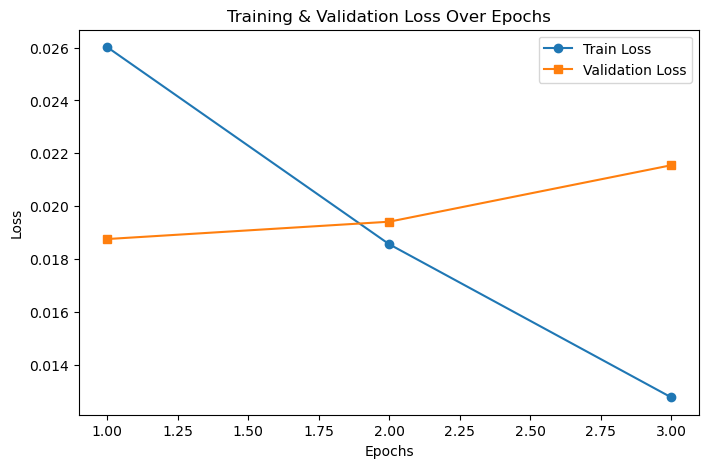

In [24]:
# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Epochs")
plt.legend()
plt.show()

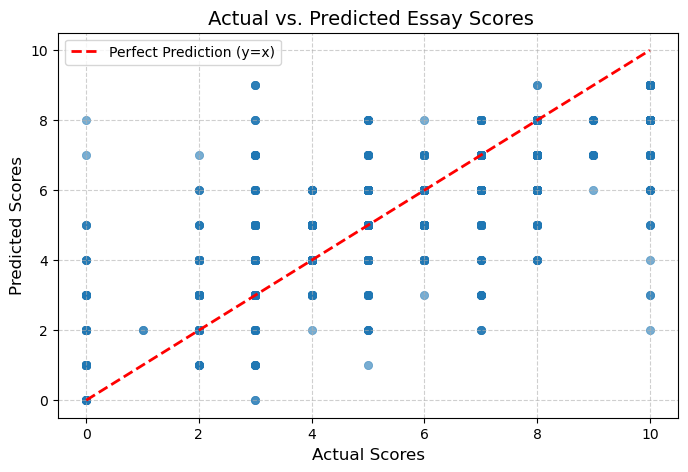

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
data = pd.read_csv("final_predictions.csv")

# Assuming the CSV file has columns 'actual_score' and 'predicted_score'
true_labels = data['Actual Score']
final_predictions = data['Predicted Score']

# Create figure
plt.figure(figsize=(8, 5))

# Add scatter plot with improved visualization
sns.scatterplot(x=true_labels, y=final_predictions, alpha=0.6, edgecolor=None)

# Add identity line (y = x) for reference
plt.plot([min(true_labels), max(true_labels)], [min(true_labels), max(true_labels)], 
         color='red', linestyle='dashed', linewidth=2, label="Perfect Prediction (y=x)")

# Improve labels and title
plt.xlabel("Actual Scores", fontsize=12)
plt.ylabel("Predicted Scores", fontsize=12)
plt.title(" Actual vs. Predicted Essay Scores", fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show plot
plt.legend()
plt.show()


In [28]:
# Generate Final Predictions
final_predictions = []
true_labels = []

model.eval()  # Set model to evaluation mode
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        scores = batch["score"].to(device)  # Use "score" not "label"

        outputs = model(input_ids, attention_mask=attention_mask).squeeze()  # No .logits needed!
        final_predictions.extend(outputs.cpu().numpy().flatten())
        true_labels.extend(scores.cpu().numpy().flatten())

# Convert predictions back to original score range
final_predictions_scaled = np.round(np.array(final_predictions) * max_score)
true_labels_scaled = np.round(np.array(true_labels) * max_score)

# Calculate QWK and EMD
final_qwk = cohen_kappa_score(final_predictions_scaled, true_labels_scaled, weights="quadratic")
final_emd = wasserstein_distance(final_predictions_scaled, true_labels_scaled)

print("\nFinal Evaluation Metrics:")
print(f"Final QWK: {final_qwk:.4f}")
print(f"Final EMD: {final_emd:.4f}")

# Save Final Predictions
predictions_df = pd.DataFrame({
    "Actual Score": true_labels_scaled,
    "Predicted Score": final_predictions_scaled
})
predictions_df.to_csv("final_predictions.csv", index=False)
print("Final predictions saved to 'final_predictions.csv'.")



Final Evaluation Metrics:
Final QWK: 0.7661
Final EMD: 0.6032
Final predictions saved to 'final_predictions.csv'.


In [1]:
essays = {
    "Repeated Sentences": """Technology is important. Technology is important. Technology is important.
                             Technology is important. Technology is important. Technology is important.
                             Technology is important. Technology is important. Technology is important.
                             Technology is important.""",

    "Reworded Sentences": """Technology is a big part of our daily lives, helping us do things faster and stay connected.  
Technology fits easily into our daily routines, making work easier and helping us talk to others.  
We use technology every day to make things simpler and stay in touch with people.  
Technology helps us work better and talk to friends and family more easily.  
Using technology makes our daily tasks easier and helps us stay connected.  
New technology makes life simpler and helps people talk to each other easily.  
Technology is very important in today’s world because it helps us do things quickly and stay in touch.  
Having technology in our daily life makes things more convenient and helps us talk instantly.  
New gadgets and tools make daily work easier and help people stay connected.  
Technology helps us in many ways, making tasks simple and keeping us close to others.""",

    "Diverse Content": """Technology has changed the way people communicate,
      making instant global connections easy and accessible. Digital platforms and social media help individuals
        and businesses collaborate across borders in real time. Artificial intelligence is transforming industries
          by automating complex tasks with high accuracy and efficiency. AI improves decision-making in areas like
            healthcare and finance, reducing errors and increasing productivity. Automation in manufacturing has boosted
              efficiency, cutting costs and reducing the need for manual labor. Online education removes geographical
                barriers, allowing students worldwide to access knowledge instantly. The internet has made information
                  widely available, giving people access to learning resources anytime. Medical technology, including
                    AI diagnostics and robotic surgeries, has greatly improved patient care. E-commerce and digital payments 
                    have changed how people shop, making transactions faster and more convenient. As AI and automation continue 
                    to grow, ethical concerns must be addressed to ensure responsible innovation."""
}

In [ ]:
def predict_score(essay):
    inputs = tokenizer(essay, return_tensors="pt", truncation=True, padding="max_length", max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        output = model(**inputs).squeeze().item()  # No .logits needed since it's a regression task

    # Convert normalized prediction back to original score range
    predicted_score = round(output * max_score)
    return predicted_score

# Get scores for each essay type
scores = {key: predict_score(value) for key, value in essays.items()}

# Display results
print("\n===== Custom Essay Evaluation =====")
for category, score in scores.items():
    print(f"{category}: {score:.4f}")



===== Custom Essay Evaluation =====
Repeated Sentences: 3.6305
Reworded Sentences: 5.2917
Diverse Content: 7.0150
